In [2]:
import pickle
import pandas as pd
import matplotlib.pyplot as plt
from upsetplot import UpSet, from_memberships

In [6]:
binding_1348_files = {
    'qcnn': '../../qcnn/experiments/exp4_binding_1234_basis_loaded/load_1348_basis.pkl',
    'cnn_small': '../../ccnn/output/limited_params/binding_results/1348/results.csv',
    'cnn_large': '../../ccnn/output/large_params/binding_results/1348/results.csv',
    'rf': '../../random_forest/experiments/binding_1348/output.txt',
    'ba_rank': '../../qcnn/input_data/IEDB_data/split_data/iedb_binding_test_small.csv'
}


# load QCNN results
with open(binding_1348_files['qcnn'], 'rb') as f:
    data = pickle.load(f)
    quantum_preds = data['test_pred']
    labels = data['test_labels']
    
    
    
# helper functions for formatting
def string_to_list(s):
    s = s.strip("[]")  # remove the brackets
    return [int(x) for x in s.split()] if s else []
def zero_to_neg(x):
    res = []
    for i in x:
        if i == 0:
            res.append(-1)
        else:
            res.append(1)
    return res


# load classical data 
df = pd.read_csv(binding_1348_files['cnn_small'])
classical_small_preds = df['pred_labels'].apply(string_to_list).apply(zero_to_neg).iloc[0]
classical_small_labels = df['test_labels'].apply(string_to_list).apply(zero_to_neg).iloc[0]
count = 0
for index, val in enumerate(classical_small_labels):
    if val != labels[index]:
        count+=1
if count > 0:
    print(f'error different labels --> {count} differ')
    

df = pd.read_csv(binding_1348_files['cnn_large'])
classical_large_preds = df['pred_labels'].apply(string_to_list).apply(zero_to_neg).iloc[0]
classical_large_labels = df['test_labels'].apply(string_to_list).apply(zero_to_neg).iloc[0]
count = 0
for index, val in enumerate(classical_large_labels):
    if val != labels[index]:
        count+=1
if count > 0:
    print(f'error different labels --> {count} differ')

# ba rank load in
df = pd.read_csv(binding_1348_files['ba_rank'])
ba_labels = zero_to_neg(df['ba_rank'].to_list())


    
# load rf data
with open(binding_1348_files['rf'], 'r') as file:
    lines = file.readlines()
    rf_labels = lines[8] + lines[9]
rf_labels = rf_labels[18:]
rf_labels = rf_labels.replace(']', '').replace('\n', '')
rf_labels = [int(i) for i in rf_labels.split(' ')]
rf_labels = [1 if i > 0 else -1 for i in rf_labels]

/home/petersr13/.local/lib/python3.11/site-packages/upsetplot/data.py:303: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(False, inplace=True)
/home/petersr13/.local/lib/python3.11/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth"].fillna(1, inpla

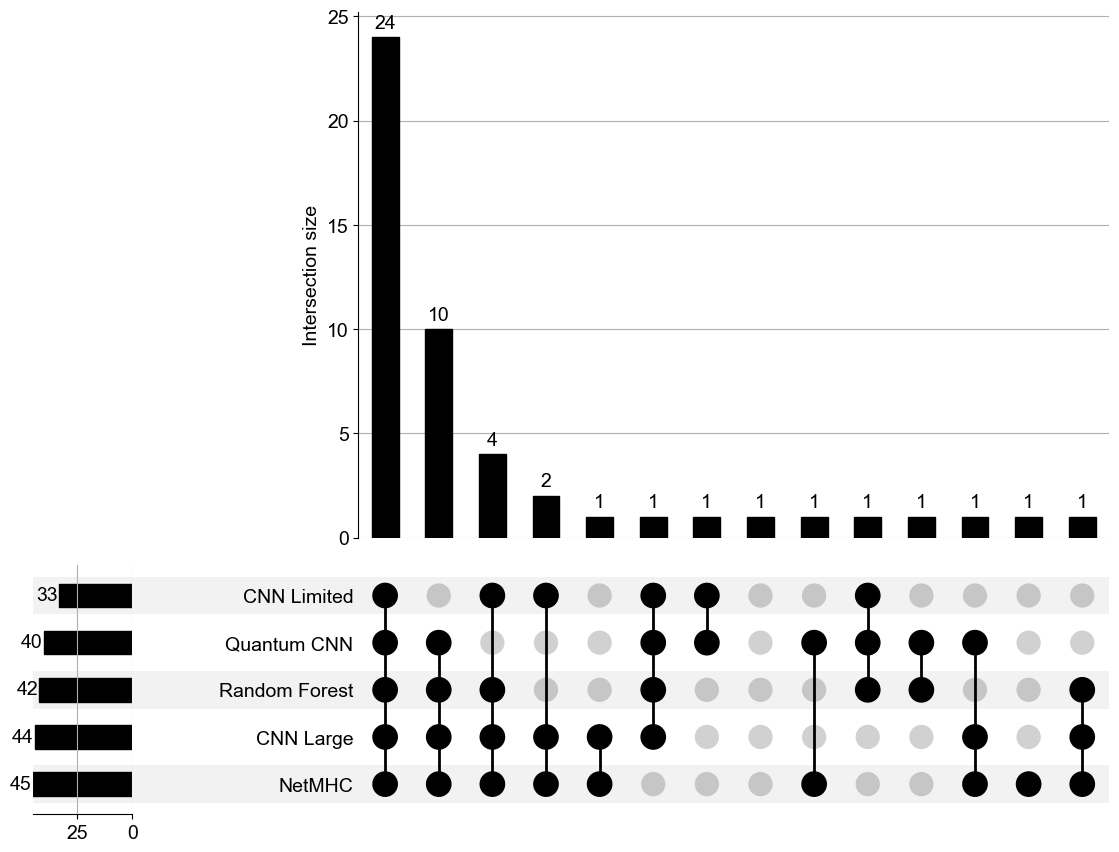

In [7]:
# Convert to labeled Series
labels = pd.Series(labels, name='true')
quantum_preds = pd.Series(quantum_preds, name='Quantum CNN')
classical_small_preds = pd.Series(classical_small_preds, name='CNN Limited')
classical_large_preds = pd.Series(classical_large_preds, name='CNN Large')
ba_labels = pd.Series(ba_labels, name='BA RANK')
rf_labels = pd.Series(rf_labels, name='Random Forest')

# Boolean arrays for correct predictions
quantum_correct = quantum_preds == labels
classical_small_correct = classical_small_preds == labels
classical_large_correct = classical_large_preds == labels
ba_correct = ba_labels == labels
rf_correct = rf_labels == labels

# Determine memberships based on correctness
memberships = []
for qc, scc, lcc, bac, rfc in zip(quantum_correct, classical_small_correct, classical_large_correct, ba_correct, rf_correct):
    mem = []
    if qc:
        mem.append('Quantum CNN')
    if scc:
        mem.append('CNN Limited')
    if lcc:
        mem.append('CNN Large')
    if bac:
        mem.append('NetMHC')
    if rfc:
        mem.append('Random Forest')
    memberships.append(mem)

# Create UpSet data
data = from_memberships(memberships)

# Plot settings
plt.rcParams.update({
    'font.family': 'Arial',
    'font.size': 14,
    'axes.titlesize': 16,
    'axes.labelsize': 14
})

fig = plt.figure(figsize=(8, 5))
up = UpSet(
    data,
    subset_size='count',
    show_counts=True,
    show_percentages=False,
    sort_by='cardinality',
    intersection_plot_elements=10,
    element_size=50
)
up.plot(fig=fig)

plt.savefig('binding_upset.svg', dpi=300, bbox_inches='tight')
plt.show()